In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_2/UGC-5823_2_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_2/UGC-5823_2_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     373   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        54   (2094, 964)   float32   


In [4]:
image_cut = image[38:138, 0:1890]
image_error_cut = image_error[38:138, 0:1890]

Text(0.5, 0, 'wavelength')

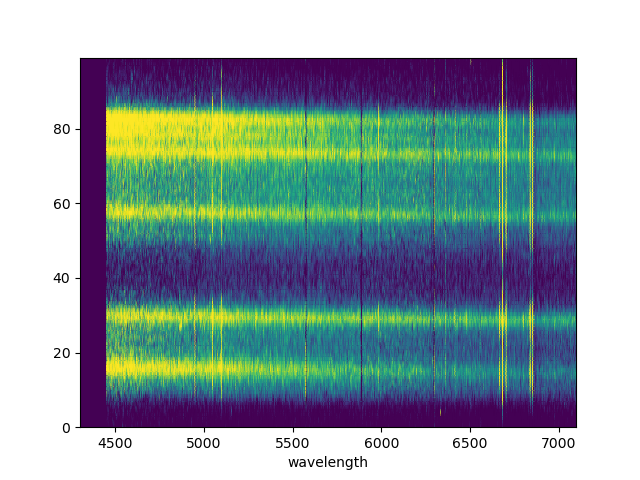

In [5]:
wavelengths = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 52*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelengths, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax=np.percentile(image_cut, 95))
plt.xlabel('wavelength')

In [6]:
z = 0.0188
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)
seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC5823/UGC5823_2/PSF/Real_seeing_UGC5823_2.txt")
sigma = seeing[0]/2.35

In [7]:
l_HB

4952.386799999999

Text(0.5, 1.0, 'H$\\alpha$')

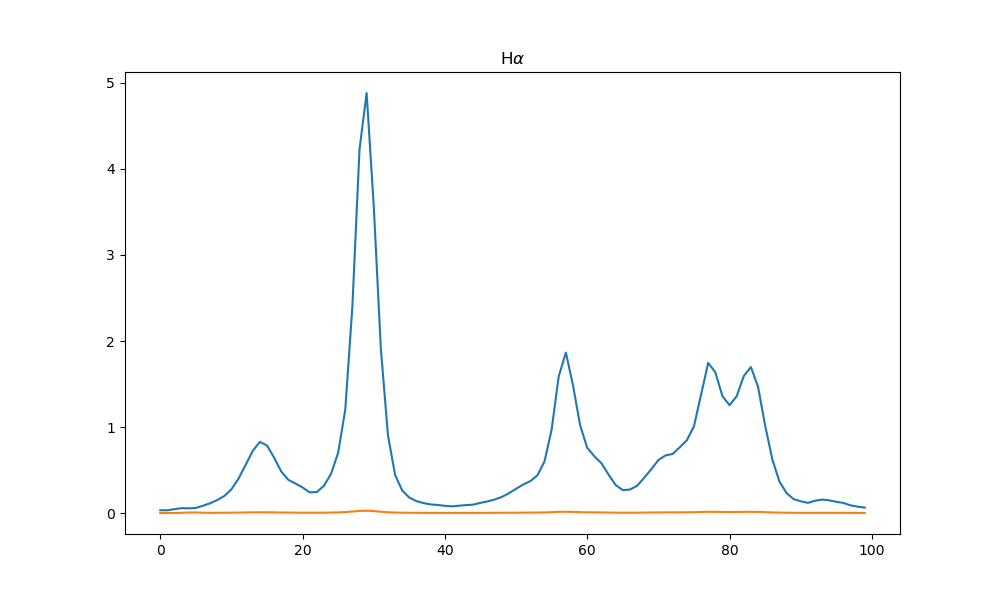

In [8]:
#Ogni punto del flusso è il risultato della somma di 20 lunghezze d'onda 
mask_HA = (wavelengths > l_HA-8)*(wavelengths < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [9]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

#Define the function for the aic
#Per l'AIC test usiamo il chi quadro perchè il numero di conteggi è elevato (S/N grande) 
#quindi Poisson --> Gauss
#def chi_quad(x, y, y_err, params):
#    return np.sum((((y - model_convolved(x, *params)) / y_err)**2))
    
def AIC(x, y, chi, params): #k=number of model parameter, N=number of data points
    return chi + 2*len(params) +((2*len(params)*(len(params)+1))/(len(y)-len(params)-1))

def BIC(x, y, chi, params):
        return chi + len(params)*np.log(len(y))
    
def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def save_params(params_curve, covariance, radial_profile, radial_profile_error, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, chi2

In [10]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params) 
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (28, 31),  # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params1 = result.x

print("Optimize parameters with differential_evolution:", best_params1)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 58.97376424456438
differential_evolution step 2: f(x)= 58.97376424456438
differential_evolution step 3: f(x)= 48.50604133174017
differential_evolution step 4: f(x)= 48.50604133174017
differential_evolution step 5: f(x)= 48.50604133174017
differential_evolution step 6: f(x)= 48.50604133174017
differential_evolution step 7: f(x)= 48.50604133174017
differential_evolution step 8: f(x)= 44.85030499141961
differential_evolution step 9: f(x)= 44.85030499141961
differential_evolution step 10: f(x)= 44.85030499141961
differential_evolution step 11: f(x)= 44.66643222254819
differential_evolution step 12: f(x)= 44.66643222254819
differential_evolution step 13: f(x)= 44.66643222254819
differential_evolution step 14: f(x)= 44.27577714750485
differential_evolution step 15: f(x)= 43.97493491519317
differential_evolution step 16: f(x)= 43.87151566502573
differential_evolution step 17: f(x)= 43.87151566502573
differential_evolution step 18: f(x)= 43.87151566502573
d

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0083, r_e=76.9930, n=5.0057, x_0=28.7914
[1.06072691e-01 6.29960887e+02 1.51686736e+01 3.47445783e-04]
1851.708296892826
1860.129349524405 0.0 1870.1289776367782 4


ValueError: operands could not be broadcast together with shapes (100,) (120,) 

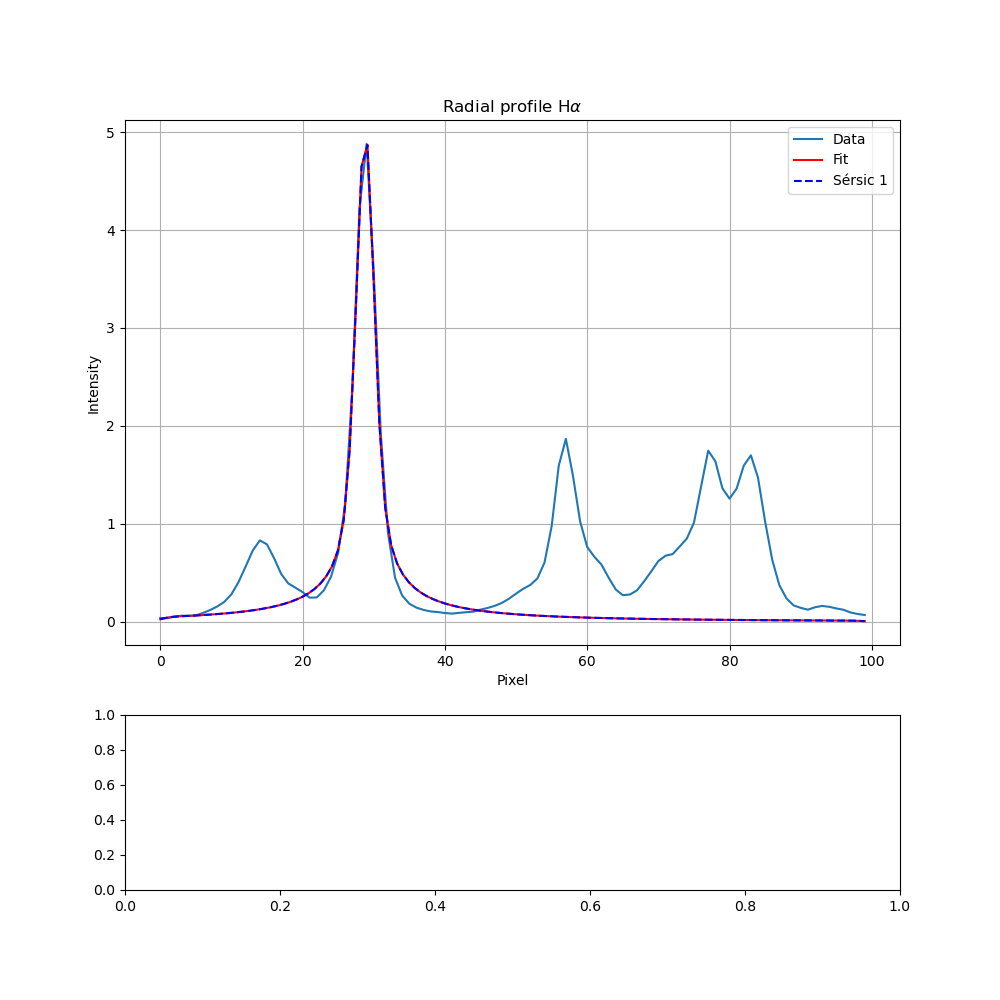

In [11]:
# Plots:
aic = np.zeros(8)
bic = np.zeros(8)
chi_quadr = np.zeros(8)
chi_quadro = np.zeros(8)
red_chi = np.zeros(8)

params_curve_1, covariance_1 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params1,
                                         sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[0], red_chi[0] = save_params(params_curve_1, covariance_1, radial_profile_HA, radial_profile_error_HA, x_axes, 1, line_name="One", 
                                           output_prefix="fit")

aic[0] = AIC(x_axes, radial_profile_HA, chi_quadr[0], params_curve_1)
bic[0] = BIC(x_axes, radial_profile_HA, chi_quadr[0], params_curve_1)
print(aic[0], chi_quadro[0], bic[0], len(params_curve_1))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 120)
y_fit = model_convolved(xgrid, *params_curve_1)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_1), 'b--', label='Sérsic 1')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)
plt.savefig('AIC_1', bbox_inches='tight')

In [12]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8])
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =  [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (28, 31),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (55, 59)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params2 = result.x

print("Optimize parameters with differential_evolution:", best_params2)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 899.0289544304754
differential_evolution step 2: f(x)= 899.0289544304754
differential_evolution step 3: f(x)= 520.5071592434604
differential_evolution step 4: f(x)= 59.55404656959826
differential_evolution step 5: f(x)= 59.55404656959826
differential_evolution step 6: f(x)= 40.49073712333399
differential_evolution step 7: f(x)= 39.82224897573204
differential_evolution step 8: f(x)= 39.82224897573204
differential_evolution step 9: f(x)= 39.82224897573204
differential_evolution step 10: f(x)= 39.82224897573204
differential_evolution step 11: f(x)= 39.82224897573204
differential_evolution step 12: f(x)= 39.82224897573204
differential_evolution step 13: f(x)= 35.708839811719514
differential_evolution step 14: f(x)= 35.708839811719514
differential_evolution step 15: f(x)= 34.80280323123106
differential_evolution step 16: f(x)= 34.80280323123106
differential_evolution step 17: f(x)= 34.80280323123106
differential_evolution step 18: f(x)= 34.80280323123106

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_5964\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_5964\223936200.py:8: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=3.2070, r_e=0.9792, n=0.7888, x_0=28.7926
Sérsic 2: I_e=0.2486, r_e=40.8403, n=0.0688, x_0=49.8237
[10.53944285  0.69088373  3.50945463  0.20758578  0.17669261  8.2869071
  0.06001806  1.72842876]
1089.4489147610727
1107.0313323434902 1089.4489147610727 1126.2902762489775 8


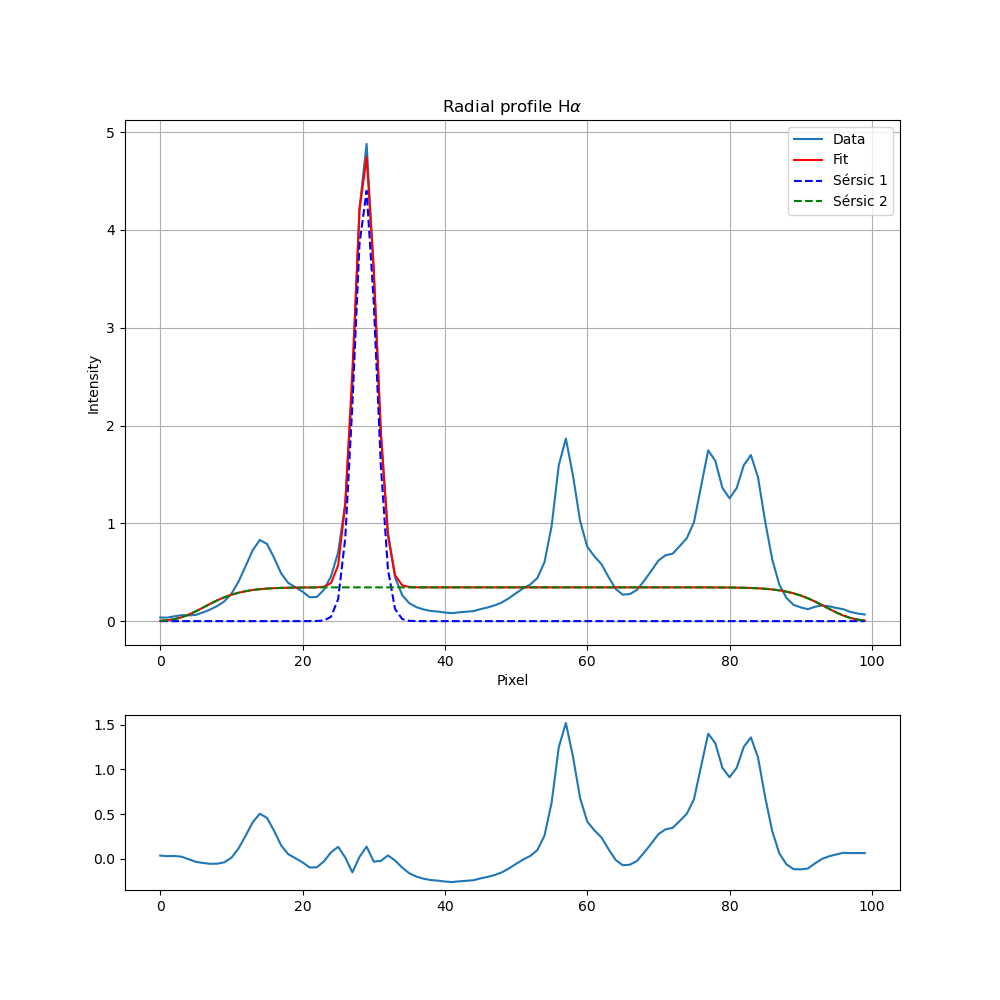

In [14]:
# Plots:
params_curve_2, covariance_2 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params2, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[1], red_chi[1] = save_params(params_curve_2, covariance_2, radial_profile_HA, radial_profile_error_HA,
    x_axes, 2, line_name="Two", output_prefix="fit")

aic[1] = AIC(x_axes, radial_profile_HA, chi_quadr[1], params_curve_2)
bic[1] = BIC(x_axes, radial_profile_HA, chi_quadr[1], params_curve_2)
print(aic[1], chi_quadr[1], bic[1], len(params_curve_2))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_2)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_2[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_2[4:8]), 'g--', label='Sérsic 2')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_2', bbox_inches='tight')

In [15]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12])
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
     (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (28, 31),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (55, 59),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (75, 79)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params3 = result.x

print("Optimize parameters with differential_evolution:", best_params3)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 4667.548339265089
differential_evolution step 2: f(x)= 1109.0747672418909
differential_evolution step 3: f(x)= 1060.1665451888152
differential_evolution step 4: f(x)= 1060.1665451888152
differential_evolution step 5: f(x)= 542.4839985549266
differential_evolution step 6: f(x)= 288.0879621871101
differential_evolution step 7: f(x)= 69.54090559726328
differential_evolution step 8: f(x)= 29.39438786557547
differential_evolution step 9: f(x)= 29.39438786557547
differential_evolution step 10: f(x)= 29.39438786557547
differential_evolution step 11: f(x)= 29.39438786557547
differential_evolution step 12: f(x)= 29.39438786557547
differential_evolution step 13: f(x)= 29.39438786557547
differential_evolution step 14: f(x)= 29.39438786557547
differential_evolution step 15: f(x)= 29.39438786557547
differential_evolution step 16: f(x)= 29.39438786557547
differential_evolution step 17: f(x)= 29.39438786557547
differential_evolution step 18: f(x)= 29.3943878655754

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_5964\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_5964\2884650973.py:9: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.0146, r_e=38.5665, n=4.8618, x_0=28.8162
Sérsic 2: I_e=0.1710, r_e=7.7006, n=1.6790, x_0=57.2264
Sérsic 3: I_e=0.7525, r_e=6.3288, n=0.5351, x_0=78.8740
[1.06546514e-01 1.74466171e+02 9.60139734e+00 9.88665740e-05
 1.86454775e-01 5.67720851e+00 8.61855203e-01 2.81797671e-01
 1.33127295e-01 5.58850007e-01 1.27746161e-01 3.87166238e-01]
320.79489976924356
348.3811066657953 320.79489976924356 376.05694200110065 12


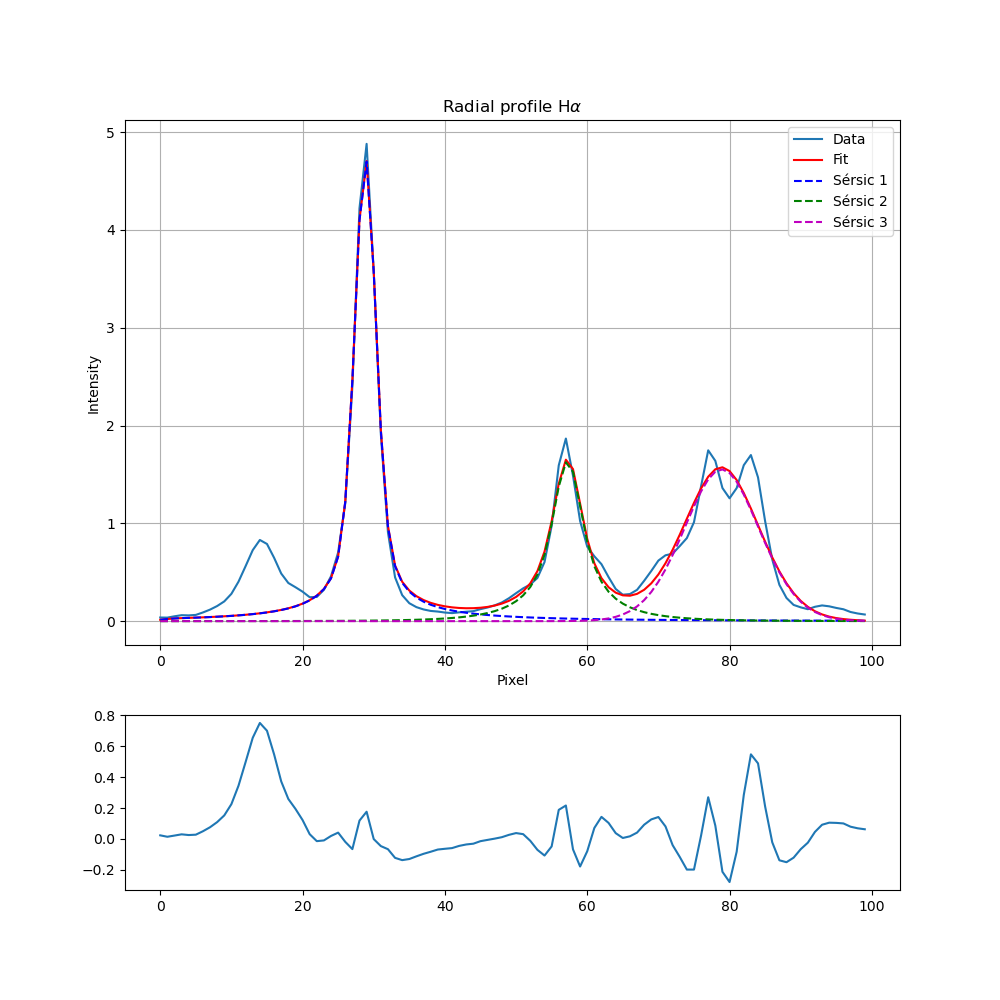

In [17]:
# Plots:
params_curve_3, covariance_3 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params3, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[2], red_chi[2] = save_params(params_curve_3, covariance_3, radial_profile_HA, radial_profile_error_HA,x_axes, 3,  
                                       line_name="Three", output_prefix="fit")

aic[2] = AIC(x_axes, radial_profile_HA, chi_quadr[2], params_curve_3)
bic[2] = BIC(x_axes, radial_profile_HA, chi_quadr[2], params_curve_3)
print(aic[2], chi_quadr[2], bic[2], len(params_curve_3))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_3)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[8:12]), 'm--', label='Sérsic 3')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_3', bbox_inches='tight')

In [24]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
     (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (28, 31),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (55, 59),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (76, 78),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (81, 83),   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params4 = result.x

print("Optimize parameters with differential_evolution:", best_params4)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 15024.582256106683
differential_evolution step 2: f(x)= 15024.582256106683
differential_evolution step 3: f(x)= 4275.626399977332
differential_evolution step 4: f(x)= 4275.626399977332
differential_evolution step 5: f(x)= 4275.626399977332
differential_evolution step 6: f(x)= 211.64564784042554
differential_evolution step 7: f(x)= 211.64564784042554
differential_evolution step 8: f(x)= 211.64564784042554
differential_evolution step 9: f(x)= 211.64564784042554
differential_evolution step 10: f(x)= 211.64564784042554
differential_evolution step 11: f(x)= 211.64564784042554
differential_evolution step 12: f(x)= 211.64564784042554
differential_evolution step 13: f(x)= 211.64564784042554
differential_evolution step 14: f(x)= 211.64564784042554
differential_evolution step 15: f(x)= 211.64564784042554
differential_evolution step 16: f(x)= 79.63379923469083
differential_evolution step 17: f(x)= 79.63379923469083
differential_evolution step 18: f(x)= 60.2554

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0384, r_e=17.0248, n=4.2403, x_0=28.7914
Sérsic 2: I_e=0.0096, r_e=47.3435, n=4.0029, x_0=56.9880
Sérsic 3: I_e=0.0729, r_e=23.3057, n=2.0613, x_0=77.2883
Sérsic 4: I_e=0.5249, r_e=1.5165, n=1.0041, x_0=83.0000
[3.31868423e-01 9.14519337e+01 1.19918975e+01 2.74611617e-04
 1.35457648e-01 4.80778589e+02 1.33751911e+01 2.00549845e-01
 1.41362111e-01 3.40414730e+01 1.46764946e+00 5.95239117e-01
 1.59522257e+00 2.02274678e+00 2.86657595e+00 3.90800078e-01]
290.77883649783996
329.33305336530987 290.77883649783996 364.46155947364946 16


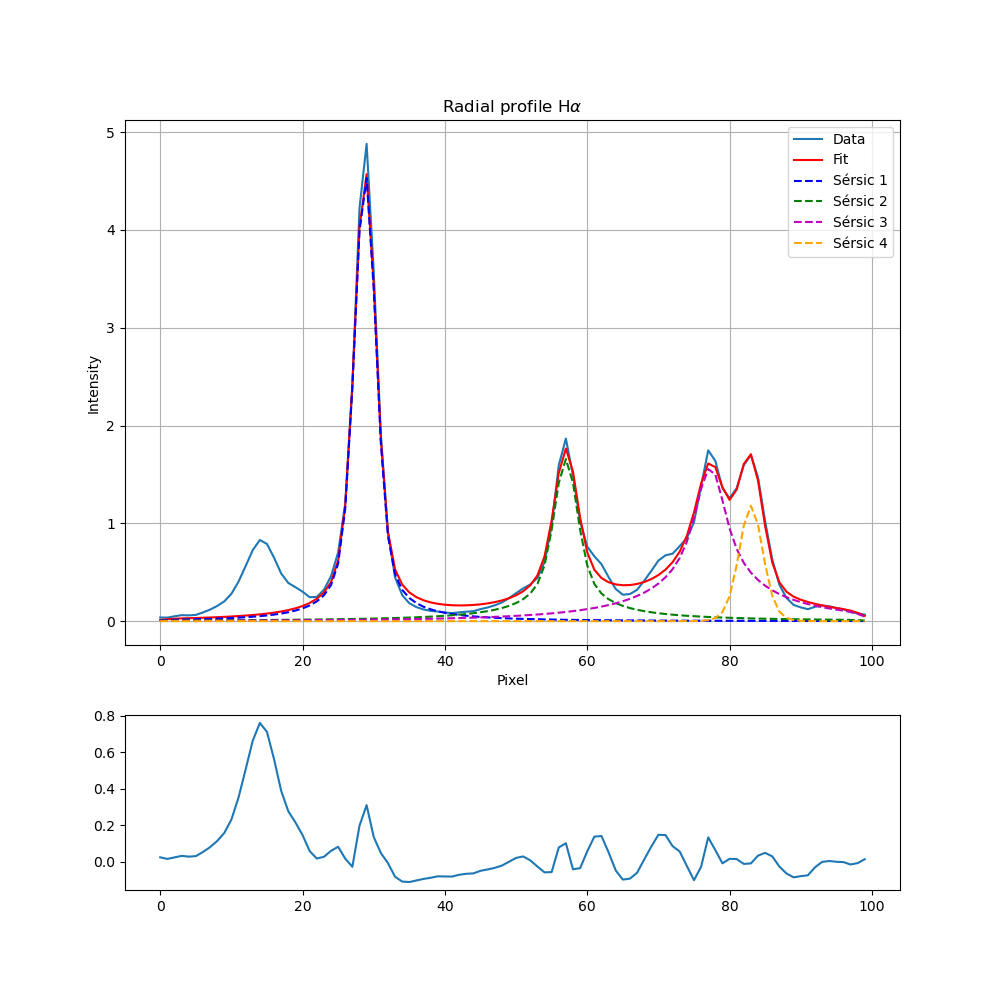

In [25]:
# Plots:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_4, covariance_4 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params4, 
                                         sigma = radial_profile_error_HA, bounds = bounds_list)

print("Optimize parameters with curve fit:")

chi_quadr[3], red_chi[3] = save_params(params_curve_4, covariance_4, radial_profile_HA, radial_profile_error_HA, x_axes, 4, line_name="Four", output_prefix="fit")

aic[3] = AIC(x_axes, radial_profile_HA, chi_quadr[3], params_curve_4)
bic[3] = BIC(x_axes, radial_profile_HA, chi_quadr[3], params_curve_4)
print(aic[3], chi_quadr[3], bic[3], len(params_curve_4))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_4)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_4', bbox_inches='tight')

In [26]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (28, 31),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (55, 59),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (76, 78),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (81, 83),     # x_0: posizione da 0 a 100
    
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (10, 16),   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params5 = result.x

print("Optimize parameters with differential_evolution:", best_params5)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 85293.96564182793
differential_evolution step 2: f(x)= 43864.01756270464
differential_evolution step 3: f(x)= 25099.880156799525
differential_evolution step 4: f(x)= 7175.6942276697655
differential_evolution step 5: f(x)= 7175.6942276697655
differential_evolution step 6: f(x)= 7175.6942276697655
differential_evolution step 7: f(x)= 5936.346879398361
differential_evolution step 8: f(x)= 5936.346879398361
differential_evolution step 9: f(x)= 5936.346879398361
differential_evolution step 10: f(x)= 5398.342096671354
differential_evolution step 11: f(x)= 1543.5798819358922
differential_evolution step 12: f(x)= 1543.5798819358922
differential_evolution step 13: f(x)= 1523.4529743146784
differential_evolution step 14: f(x)= 1523.4529743146784
differential_evolution step 15: f(x)= 195.78168326387308
differential_evolution step 16: f(x)= 195.78168326387308
differential_evolution step 17: f(x)= 195.78168326387308
differential_evolution step 18: f(x)= 195.7816

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_5964\111436280.py:9: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_5964\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_5964\2384567265.py:11: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.2767, r_e=4.4107, n=2.8108, x_0=28.8162
Sérsic 2: I_e=0.0810, r_e=11.7250, n=2.2757, x_0=57.0396
Sérsic 3: I_e=0.1513, r_e=13.8219, n=1.5828, x_0=77.3796
Sérsic 4: I_e=0.0110, r_e=8.9110, n=5.4461, x_0=83.0498
Sérsic 5: I_e=0.1078, r_e=7.8454, n=1.4474, x_0=14.3292
[2.84012340e-01 2.39825522e+00 2.49972722e+00 8.72864744e-04
 6.00871879e-02 6.55187331e+00 5.82517495e-01 8.53940708e-02
 6.47977414e-02 5.19632243e+00 3.06208250e-01 1.97622654e-01
 1.77954113e-01 9.02351545e+01 1.68580119e+01 1.06978027e-01
 4.75687920e-02 2.39924405e+00 3.30300757e-01 1.47848572e-01]
29.53654881007369
80.16946020247876 29.53654881007369 121.63995252983554 20


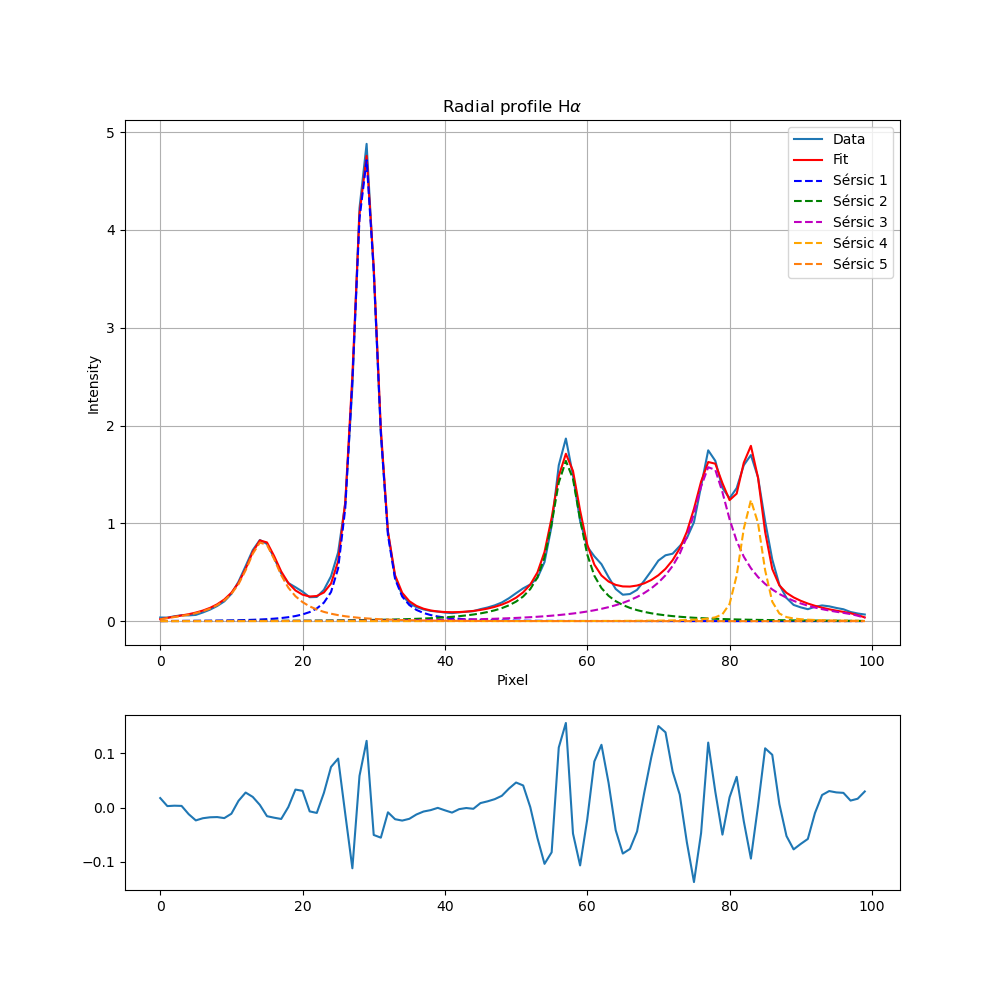

In [28]:
# Plots:
params_curve_5, covariance_5 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params5, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[4], red_chi[4] = save_params(params_curve_5, covariance_5, radial_profile_HA, radial_profile_error_HA, x_axes, 5, line_name="Five", output_prefix="fit")

aic[4] = AIC(x_axes, radial_profile_HA, chi_quadr[4], params_curve_5)
bic[4] = BIC(x_axes, radial_profile_HA, chi_quadr[4], params_curve_5)
print(aic[4], chi_quadr[4], bic[4], len(params_curve_5))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_5)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[16:20]),  linestyle='--', label='Sérsic 5')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)
plt.savefig('AIC_5', bbox_inches='tight')

In [29]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =[
   (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (28, 31),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (55, 59),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (75, 79),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (80, 85),     # x_0: posizione da 0 a 100
    
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (10, 16),   # x_0: posizione da 0 a 100

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (68, 73)   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params6 = result.x

print("Optimize parameters with differential_evolution:", best_params6)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 43833.26035457132
differential_evolution step 2: f(x)= 18501.972358982897
differential_evolution step 3: f(x)= 18501.972358982897
differential_evolution step 4: f(x)= 18501.972358982897
differential_evolution step 5: f(x)= 18501.972358982897
differential_evolution step 6: f(x)= 18501.972358982897
differential_evolution step 7: f(x)= 18501.972358982897
differential_evolution step 8: f(x)= 18501.972358982897
differential_evolution step 9: f(x)= 16141.353231271945
differential_evolution step 10: f(x)= 2390.4604475123742
differential_evolution step 11: f(x)= 1775.108522380171
differential_evolution step 12: f(x)= 1775.108522380171
differential_evolution step 13: f(x)= 1775.108522380171
differential_evolution step 14: f(x)= 1775.108522380171
differential_evolution step 15: f(x)= 711.3389799442107
differential_evolution step 16: f(x)= 711.3389799442107
differential_evolution step 17: f(x)= 430.68151482010694
differential_evolution step 18: f(x)= 430.68151

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_5964\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_5964\2414547421.py:12: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.5020, r_e=3.0457, n=2.3079, x_0=28.8157
Sérsic 2: I_e=0.1599, r_e=5.7835, n=1.8549, x_0=57.0382
Sérsic 3: I_e=0.2429, r_e=2.9773, n=1.6027, x_0=77.3692
Sérsic 4: I_e=0.7274, r_e=1.9404, n=0.6977, x_0=82.9248
Sérsic 5: I_e=0.1431, r_e=6.1382, n=1.2380, x_0=14.3837
Sérsic 6: I_e=0.0163, r_e=86.3786, n=2.2389, x_0=72.3364
[1.82010522e-01 5.92389004e-01 4.29229492e-01 2.87915686e-02
 7.82872527e-02 1.97748987e+00 4.65422050e-01 7.13828013e-02
 1.11209662e+00 9.98570965e+00 3.45587389e+00 1.37235066e-01
 2.69028514e-01 5.27477075e-01 3.51007796e-01 1.71582728e-01
 4.87710372e-02 1.44778660e+00 2.56558882e-01 1.25985708e-01
 1.95163509e-02 8.17581098e+01 6.60444906e-01 5.70024943e-01]
21.047509435562574
85.04750943556257 21.047509435562574 131.57159389927676 24


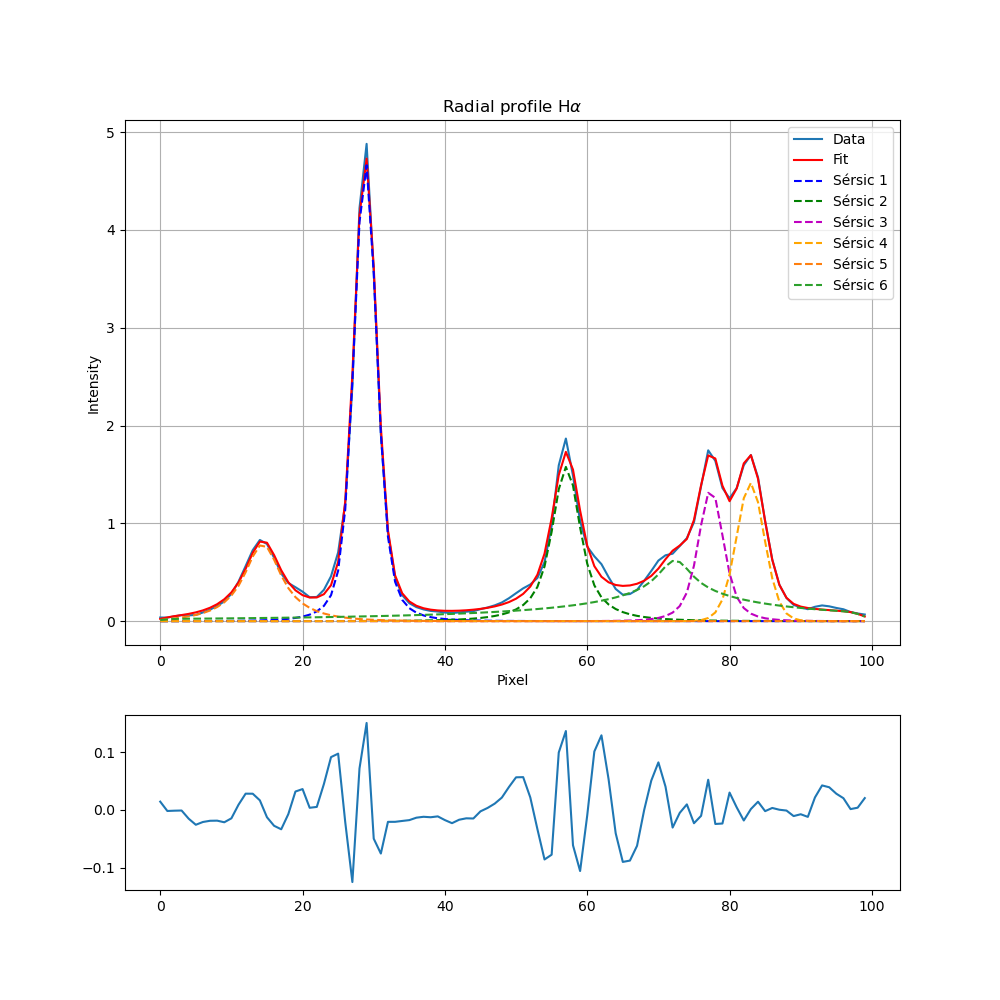

In [31]:
# Plots:
params_curve_6, covariance_6 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params6, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[5], red_chi[5] = save_params(params_curve_6, covariance_6, radial_profile_HA, radial_profile_error_HA, x_axes, 6, line_name="Six", output_prefix="fit")

aic[5] = AIC(x_axes, radial_profile_HA, chi_quadr[5], params_curve_6)
bic[5] = BIC(x_axes, radial_profile_HA, chi_quadr[5], params_curve_6)
print(aic[5], chi_quadr[5], bic[5], len(best_params6))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_6)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[16:20]),  linestyle='--', label='Sérsic 5')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[20:24]),  linestyle='--', label='Sérsic 6')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)

plt.savefig('AIC_6', bbox_inches='tight')

In [35]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24]) +
        sersic_1d(x_hr, *params[24:28])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =[
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (28, 31),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (55, 59),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (75, 79),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (80, 85),     # x_0: posizione da 0 a 100
    
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (10, 16),   # x_0: posizione da 0 a 100

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (68, 70),   # x_0: posizione da 0 a 100

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params7 = result.x

print("Optimize parameters with differential_evolution:", best_params7)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 152444.4409366518
differential_evolution step 2: f(x)= 126181.91111075206
differential_evolution step 3: f(x)= 34938.11432951084
differential_evolution step 4: f(x)= 34938.11432951084
differential_evolution step 5: f(x)= 34938.11432951084
differential_evolution step 6: f(x)= 34938.11432951084
differential_evolution step 7: f(x)= 34938.11432951084
differential_evolution step 8: f(x)= 15360.084448629194
differential_evolution step 9: f(x)= 15360.084448629194
differential_evolution step 10: f(x)= 15360.084448629194
differential_evolution step 11: f(x)= 15360.084448629194
differential_evolution step 12: f(x)= 15360.084448629194
differential_evolution step 13: f(x)= 15360.084448629194
differential_evolution step 14: f(x)= 15360.084448629194
differential_evolution step 15: f(x)= 15360.084448629194
differential_evolution step 16: f(x)= 15360.084448629194
differential_evolution step 17: f(x)= 15360.084448629194
differential_evolution step 18: f(x)= 9544.928

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_5964\111436280.py:9: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution: [1.62613540e+00 1.52480966e+00 1.32971861e+00 2.88079787e+01
 1.34146190e-01 6.46895035e+00 1.99766005e+00 5.70810073e+01
 3.08141623e-01 5.58041710e+00 1.13008868e+00 7.75482607e+01
 5.42173292e-01 1.38976933e+00 1.11626396e+00 8.32464918e+01
 1.05579111e-01 8.22038525e+00 1.39244145e+00 1.47040578e+01
 2.51059859e+00 3.11378221e-02 1.65545763e+00 6.97742339e+01
 5.70019453e-02 4.43710599e+01 8.23845658e-01 6.83550121e+01]
Chi quadro minimo: 0.3694444478418197


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_5964\111436280.py:9: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_5964\2750497257.py:13: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.4368, r_e=3.3959, n=2.3987, x_0=28.7915
Sérsic 2: I_e=0.0812, r_e=11.0631, n=2.2946, x_0=57.0878
Sérsic 3: I_e=0.3467, r_e=5.1313, n=1.0617, x_0=77.3630
Sérsic 4: I_e=0.9452, r_e=1.3716, n=0.4719, x_0=83.1938
Sérsic 5: I_e=0.1134, r_e=7.8341, n=1.4055, x_0=14.3670
Sérsic 6: I_e=1.9034, r_e=0.0229, n=1.6442, x_0=69.7874
Sérsic 7: I_e=0.0780, r_e=24.3189, n=0.4694, x_0=77.9387
[4.29110053e-01 1.88710383e+00 2.15429625e+00 1.61864330e-02
 4.67379957e-01 5.31992409e+01 4.95676328e+00 5.27618463e-02
 3.26647089e-01 5.72893228e+00 6.88540242e-01 1.92490952e-01
 7.65544557e-01 3.65788666e-01 7.06710125e-01 1.32086701e-01
 4.25461689e-02 2.44589210e+00 2.78107386e-01 1.27962835e-01
 8.34534935e+05 2.03719557e+03 3.26316883e+05 8.01222443e+01
 2.05920724e-01 1.75265091e+01 1.84315170e+00 3.84247711e+01]
19.23683650347526
98.11007594009499 19.23683650347526 148.1816017111418 28


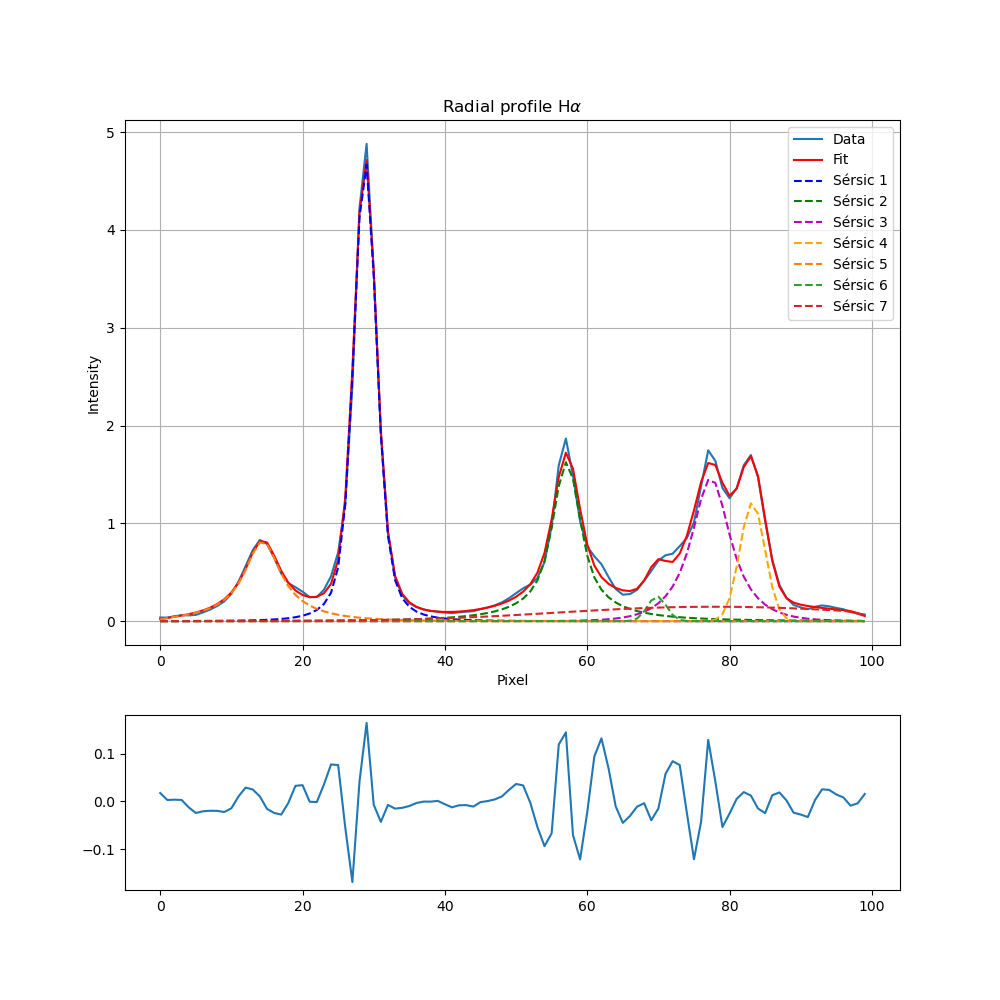

In [36]:
# Plots:
params_curve_7, covariance_7 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params7, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[6], red_chi[6] = save_params(params_curve_7, covariance_7, radial_profile_HA, radial_profile_error_HA, x_axes, 7, 
                                       line_name="Seven", output_prefix="fit")

aic[6] = AIC(x_axes, radial_profile_HA, chi_quadr[6], params_curve_7)
bic[6] = BIC(x_axes, radial_profile_HA, chi_quadr[6], params_curve_7)
print(aic[6], chi_quadr[6], bic[6], len(best_params7))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_7)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[16:20]),  linestyle='--', label='Sérsic 5')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[20:24]),  linestyle='--', label='Sérsic 6')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[24:28]),  linestyle='--', label='Sérsic 7')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(x_axes, radial_profile_HA - y_fit)

plt.savefig('AIC_7', bbox_inches='tight')

In [37]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24]) +
        sersic_1d(x_hr, *params[24:28]) +
        sersic_1d(x_hr, *params[28:32])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =[
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (28, 31),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (55, 59),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (75, 79),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (80, 85),     # x_0: posizione da 0 a 100
    
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (10, 16),   # x_0: posizione da 0 a 100

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (68, 70),   # x_0: posizione da 0 a 100

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params8 = result.x

print("Optimize parameters with differential_evolution:", best_params8)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 283951.22405295575
differential_evolution step 2: f(x)= 180641.2040930393
differential_evolution step 3: f(x)= 180641.2040930393
differential_evolution step 4: f(x)= 72459.78476968578
differential_evolution step 5: f(x)= 72459.78476968578
differential_evolution step 6: f(x)= 72459.78476968578
differential_evolution step 7: f(x)= 28034.610518755468
differential_evolution step 8: f(x)= 28034.610518755468
differential_evolution step 9: f(x)= 28034.610518755468
differential_evolution step 10: f(x)= 28034.610518755468
differential_evolution step 11: f(x)= 28034.610518755468
differential_evolution step 12: f(x)= 16720.818005012174
differential_evolution step 13: f(x)= 16720.818005012174
differential_evolution step 14: f(x)= 11891.907785897896
differential_evolution step 15: f(x)= 11891.907785897896
differential_evolution step 16: f(x)= 11891.907785897896
differential_evolution step 17: f(x)= 11891.907785897896
differential_evolution step 18: f(x)= 11891.9

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_5964\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_5964\1396728411.py:14: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.4673, r_e=2.9550, n=2.4318, x_0=28.8162
Sérsic 2: I_e=0.2386, r_e=4.2322, n=1.5825, x_0=57.0748
Sérsic 3: I_e=0.0695, r_e=8.0123, n=2.5367, x_0=77.3743
Sérsic 4: I_e=0.9256, r_e=1.7194, n=0.4863, x_0=82.9394
Sérsic 5: I_e=0.2507, r_e=2.7678, n=0.8109, x_0=14.1695
Sérsic 6: I_e=0.0133, r_e=99.9954, n=2.2913, x_0=72.0653
Sérsic 7: I_e=0.0553, r_e=1.4581, n=0.6342, x_0=49.8815
Sérsic 8: I_e=0.0963, r_e=8.9946, n=0.3863, x_0=17.9352
[7.60145686e-01 3.62786678e+00 2.10280611e+00 1.24982242e-02
 2.05928636e-01 2.70193565e+00 6.56119343e-01 7.07918517e-02
 2.56780437e-01 2.27019562e+01 2.85543815e+00 1.28027149e-01
 3.40750982e-01 2.80560740e-01 3.14469454e-01 1.36403074e-01
 1.68763056e-01 1.67151110e+00 5.42824573e-01 1.71041413e-01
 4.82939580e-02 2.60952786e+02 2.58420069e+00 5.05902659e-01
 3.06990346e-01 3.10732399e+00 4.79334194e+00 7.15410294e-01
 4.02529253e-02 8.39404772e+00 3.48353074e-01 1.51174030e+01]
17.4354171854913
112.95780

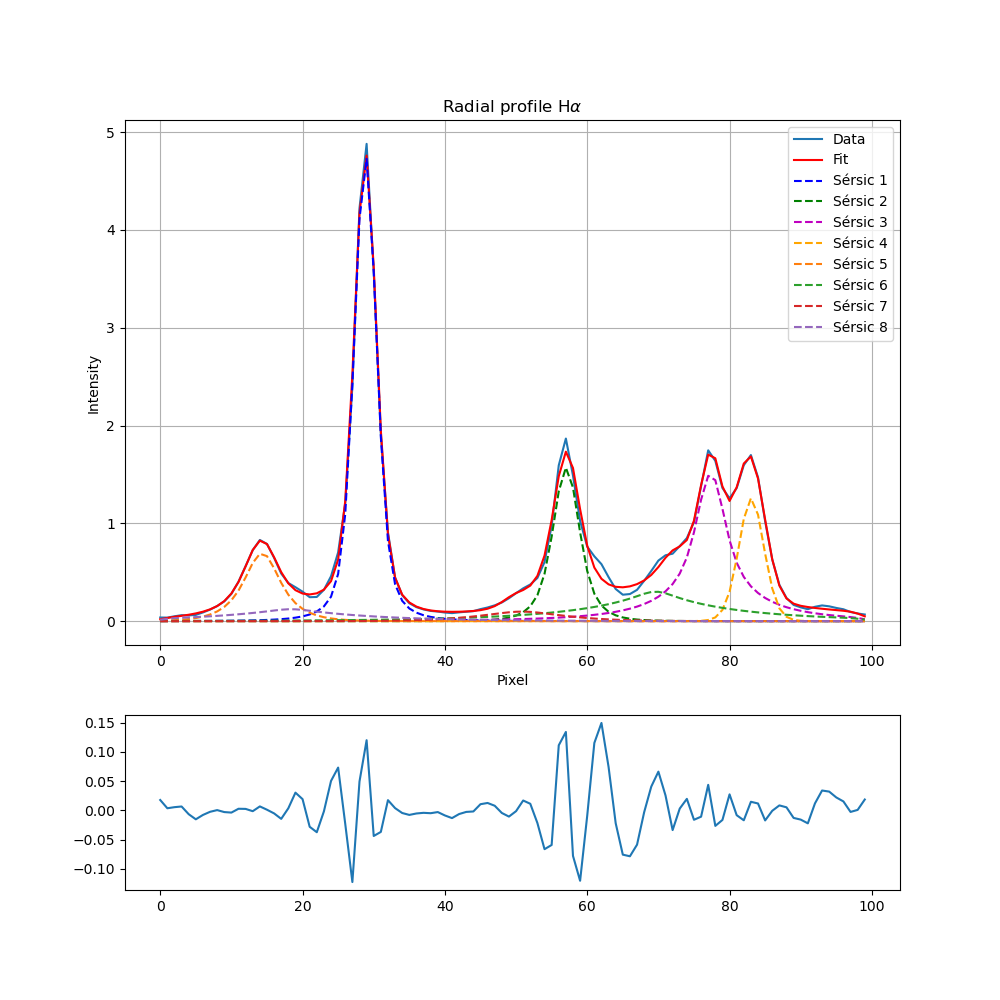

In [39]:
# Plots:
params_curve_8, covariance_8 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, 
                                         p0=best_params8, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[7], red_chi[7] = save_params(params_curve_8, covariance_8, radial_profile_HA, radial_profile_error_HA, x_axes, 8, 
                                       line_name="Eight", output_prefix="fit")

aic[7] = AIC(x_axes, radial_profile_HA, chi_quadr[7], params_curve_8)
bic[7] = BIC(x_axes, radial_profile_HA, chi_quadr[7], params_curve_8)
print(aic[7], chi_quadr[7], bic[7], len(best_params8))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_8)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params8[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params8[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params8[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params8[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params8[16:20]),  linestyle='--', label='Sérsic 5')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params8[20:24]), linestyle='--', label='Sérsic 6')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params8[24:28]), linestyle='--', label='Sérsic 7')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params8[28:32]), linestyle='--', label='Sérsic 8')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(x_axes, radial_profile_HA - y_fit)
plt.savefig('AIC_8', bbox_inches='tight')

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_5964\1271746709.py:25: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig3 = plt.figure(figsize=(8,6))


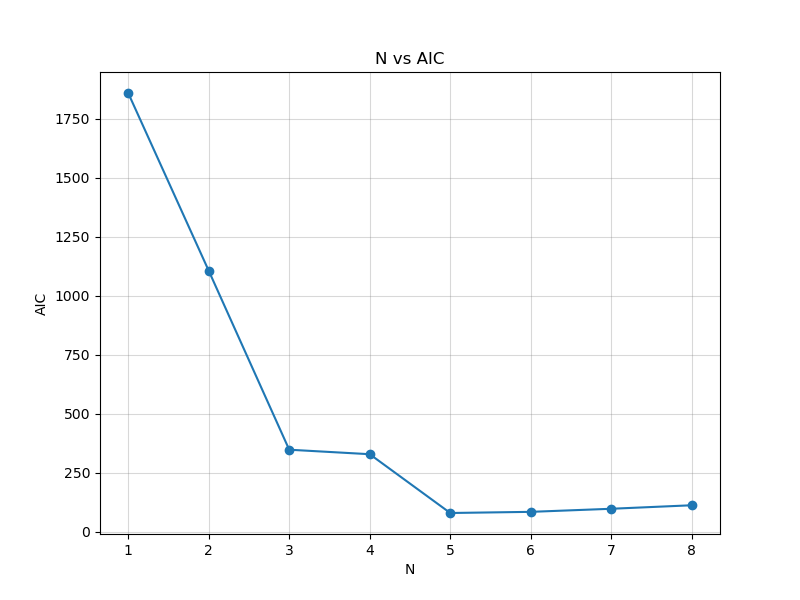

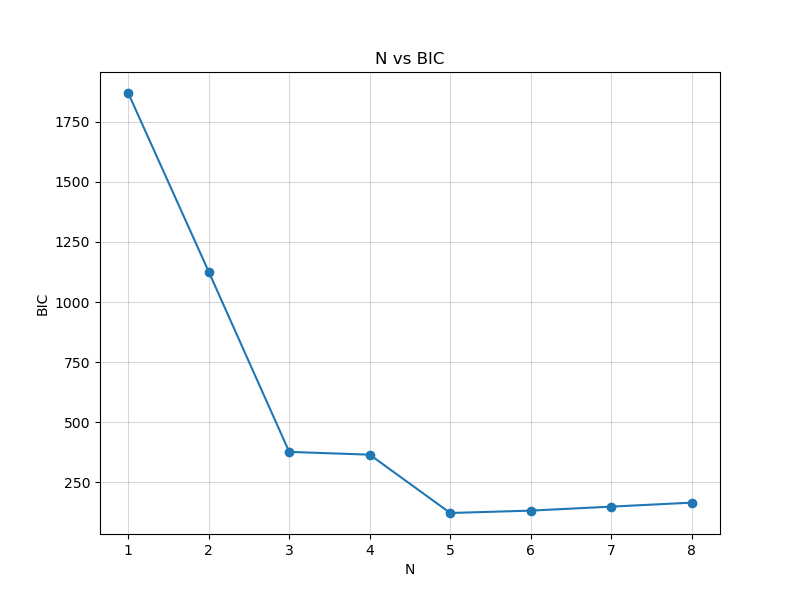

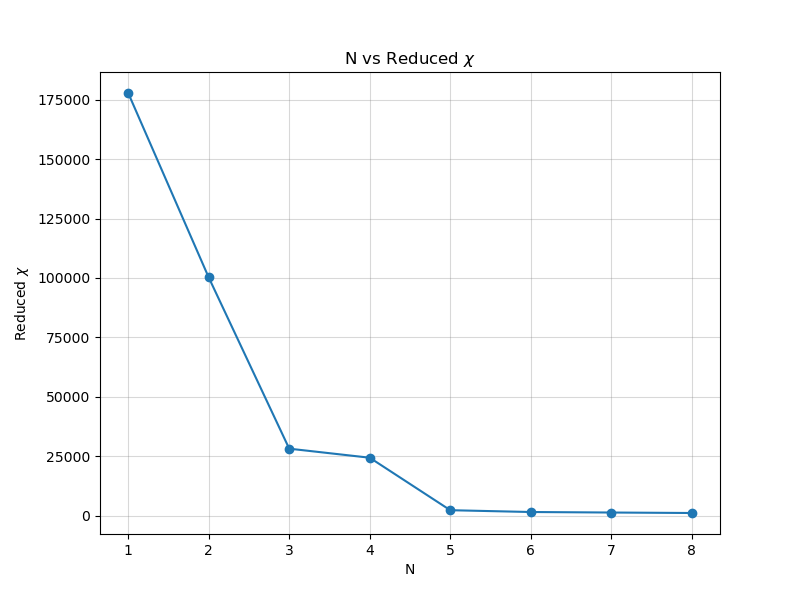

In [40]:
#Plot AIC vs N 
n = [1, 2, 3, 4, 5, 6, 7, 8]

fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.gca()
ax1.grid(alpha=0.3, c = 'grey')
ax1.set_xlabel('N')
ax1.set_ylabel('AIC')
ax1.set_title('N vs AIC')
ax1.plot(n, aic, marker = 'o')
plt.savefig('AIC_vs_N')
np.savetxt('AIC', aic)
np.savetxt('Reduced_chi', red_chi)

fig2 = plt.figure(figsize=(8,6))
ax2 = fig2.gca()
ax2.grid(alpha=0.3, c = 'grey')
ax2.set_xlabel('N')
ax2.set_ylabel('BIC')
ax2.set_title('N vs BIC')
ax2.plot(n, bic, marker = 'o')
plt.savefig('BIC_vs_N')
np.savetxt('BIC', aic)

fig3 = plt.figure(figsize=(8,6))
ax3 = fig3.gca()
ax3.grid(alpha=0.3, c = 'grey')
ax3.set_xlabel('N')
ax3.set_ylabel('Reduced $\chi$')
ax3.set_title('N vs Reduced $\chi$')
ax3.plot(n, red_chi, marker = 'o')
plt.savefig('Reduced_chi_vs_N')

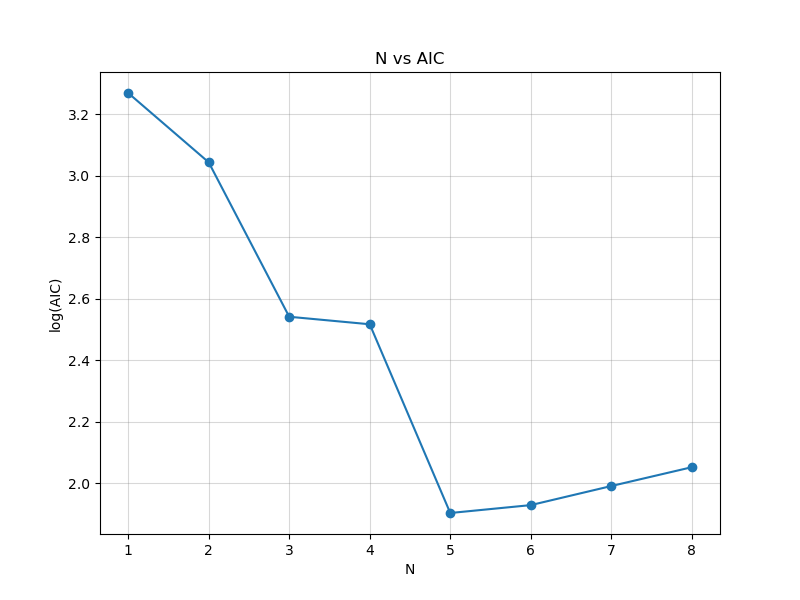

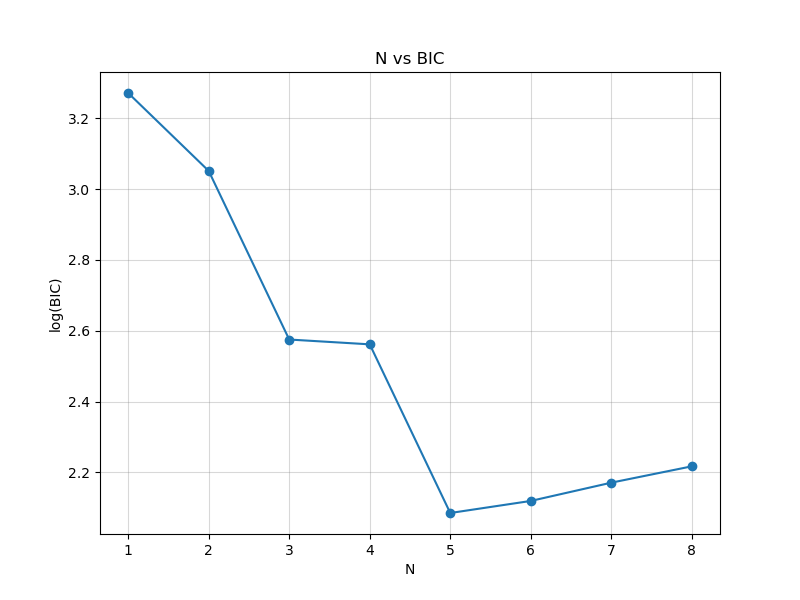

In [41]:
fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.gca()
ax1.grid(alpha=0.3, c = 'grey')
ax1.set_xlabel('N')
ax1.set_ylabel('log(AIC)')
ax1.set_title('N vs AIC')
ax1.plot(n, np.log10(aic), marker = 'o')
plt.savefig('AIC_vs_N_log')

fig2 = plt.figure(figsize=(8,6))
ax2 = fig2.gca()
ax2.grid(alpha=0.3, c = 'grey')
ax2.set_xlabel('N')
ax2.set_ylabel('log(BIC)')
ax2.set_title('N vs BIC')
ax2.plot(n, np.log10(bic), marker = 'o')
plt.savefig('BIC_vs_N_log')